In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load car dataset
df_cars = pd.read_csv(r"Data\pakwheels_used_car_data_v02.csv")

print(f"Dataset shape: {df_cars.shape}")
print(f"Columns: {list(df_cars.columns)}")

Dataset shape: (77878, 14)
Columns: ['addref', 'city', 'assembly', 'body', 'make', 'model', 'year', 'engine', 'transmission', 'fuel', 'color', 'registered', 'mileage', 'price']


In [3]:
# Display first 5 rows
print("First 5 rows:")
display(df_cars.head())

print("\nDataset info:")
print(df_cars.info())

print("\nBasic statistics:")
print(df_cars.describe())

First 5 rows:


,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,NaN,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,NaN,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,NaN,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,NaN,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0
4,7923484,Lahore,NaN,Sedan,Honda,Civic,2017.0,1800.0,Automatic,Petrol,Grey,Lahore,86000,4850000.0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77878 entries, 0 to 77877
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   addref        77878 non-null  int64  
 1   city          77878 non-null  object 
 2   assembly      24189 non-null  object 
 3   body          68974 non-null  object 
 4   make          77878 non-null  object 
 5   model         77878 non-null  object 
 6   year          73099 non-null  float64
 7   engine        77875 non-null  float64
 8   transmission  77878 non-null  object 
 9   fuel          76972 non-null  object 
 10  color         76398 non-null  object 
 11  registered    77878 non-null  object 
 12  mileage       77878 non-null  int64  
 13  price         77295 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 8.3+ MB
None

Basic statistics:
             addref          year        engine         mileage         price
count  7.787800e+04  730

In [4]:
# Check missing values
print("Missing values:")
print(df_cars.isnull().sum())

print("\nMissing values percentage:")

print((df_cars.isnull().sum() / len(df_cars)) * 100)

Missing values:
addref              0
city                0
assembly        53689
body             8904
make                0
model               0
year             4779
engine              3
transmission        0
fuel              906
color            1480
registered          0
mileage             0
price             583
dtype: int64

Missing values percentage:
addref           0.000000
city             0.000000
assembly        68.939880
body            11.433267
make             0.000000
model            0.000000
year             6.136521
engine           0.003852
transmission     0.000000
fuel             1.163358
color            1.900408
registered       0.000000
mileage          0.000000
price            0.748607
dtype: float64


In [5]:
# Handling missing values

#assembly col has alot of missing values 68% so either drop that col or if you need fill it with unknown for missing values I am dropping it
df_cars = df_cars.drop('assembly', axis=1) #dropping this col cuz its mostly empty

# Fill numerical columns with median
numerical_cols_cars = df_cars.select_dtypes(include=[np.number]).columns
df_cars[numerical_cols_cars] = df_cars[numerical_cols_cars].fillna(df_cars[numerical_cols_cars].median())

# Fill categorical columns with mode (most repeating value)
# Later observed that some cols have alot of unique value so you should fill the cols with high unique values with missing/unknown value rather then mode 
categorical_cols_cars = df_cars.select_dtypes(include=['object']).columns
for col in categorical_cols_cars:
    df_cars[col] = df_cars[col].fillna(df_cars[col].mode()[0])

print("Missing values after handling:")
print(df_cars.isnull().sum())
df_cars.head()

Missing values after handling:
addref          0
city            0
body            0
make            0
model           0
year            0
engine          0
transmission    0
fuel            0
color           0
registered      0
mileage         0
price           0
dtype: int64


,addref,city,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0
4,7923484,Lahore,Sedan,Honda,Civic,2017.0,1800.0,Automatic,Petrol,Grey,Lahore,86000,4850000.0


In [6]:
# One-hot encode categorical variables
print(f"Original {df_cars.shape}")
df_cars_encoded = pd.get_dummies(df_cars, columns=categorical_cols_cars, drop_first=True)

print(f"Dataset shape after encoding: {df_cars_encoded.shape}")
print(f"New columns added: {df_cars_encoded.shape[1] - df_cars.shape[1]}")


Original (77878, 13)
Dataset shape after encoding: (77878, 1340)
New columns added: 1327


In [7]:
# After running baove cell we can see one hot encoding doesnt work as there are too many unique values in some categorical columns
# Lets identify the columns which have many unique values
print("CATEGORICAL COLUMNS ANALYSIS:")

categorical_cols_cars = df_cars.select_dtypes(include=['object']).columns
for col in categorical_cols_cars:
    unique_count = df_cars[col].nunique()
    print(f"{col}: {unique_count} unique values")
    
    # Show top 5 most frequent values
    print(f"  Top 5 values: {df_cars[col].value_counts().head().to_dict()}")
    print()

print(f"Total unique values across all categorical columns: {sum([df_cars[col].nunique() for col in categorical_cols_cars])}")

CATEGORICAL COLUMNS ANALYSIS:
city: 297 unique values
  Top 5 values: {'Lahore': 16674, 'Karachi': 14430, 'Islamabad': 11501, 'Rawalpindi': 5448, 'Peshawar': 3689}

body: 21 unique values
  Top 5 values: {'Sedan': 39097, 'Hatchback': 25014, 'SUV': 5087, 'Crossover': 2156, 'Mini Van': 1337}

make: 68 unique values
  Top 5 values: {'Toyota': 24910, 'Suzuki': 22347, 'Honda': 16428, 'Daihatsu': 3181, 'KIA': 1764}

model: 435 unique values
  Top 5 values: {'Corolla': 12871, 'Civic': 8275, 'City': 5277, 'Mehran': 4588, 'Cultus': 4463}

transmission: 2 unique values
  Top 5 values: {'Automatic': 42763, 'Manual': 35115}

fuel: 3 unique values
  Top 5 values: {'Petrol': 71526, 'Diesel': 3457, 'Hybrid': 2895}

color: 396 unique values
  Top 5 values: {'White': 22924, 'Silver': 8173, 'Black': 7014, 'Grey': 4173, 'Solid White': 4073}

registered: 121 unique values
  Top 5 values: {'Islamabad': 18942, 'Lahore': 18739, 'Karachi': 10838, 'Sindh': 9906, 'Punjab': 9414}

Total unique values across all 

In [8]:
# Cell 15: Smart Categorical Encoding required here we need to seprate cols that have low medium and high unique values
print("SMART CATEGORICAL ENCODING: ")

# Categorize columns by cardinality
low_unique_vals = []    # if 5 or less unique values -> One-Hot
medium_unique_vals = [] # if 5-130 unique values -> Label Encoding  
high_unique_vals = []   # if more then 100 unique values -> Target Encoding

for col in categorical_cols_cars:
    unique_count = df_cars[col].nunique()
    if unique_count <= 5:
        low_unique_vals.append(col)
    elif unique_count <= 130:
        medium_unique_vals.append(col)
    else:
        high_unique_vals.append(col)

print(f"Low Unique Values (One-Hot): {low_unique_vals}")
print(f"Medium Unique Values (Label): {medium_unique_vals}")  
print(f"High Unique Values (Target): {high_unique_vals}")


SMART CATEGORICAL ENCODING: 
Low Unique Values (One-Hot): ['transmission', 'fuel']
Medium Unique Values (Label): ['body', 'make', 'registered']
High Unique Values (Target): ['city', 'model', 'color']


In [9]:
# Cell 16: Apply different encoding for different c

# I'm doing different encoding for different columns with low medium and high nbr of unique values but you can also 
# use top n unique value and make other of other values which are not in top n and do one-hot encoding
df_cars_encoded = df_cars.copy()

# 1. ONE-HOT ENCODING for columns with low unique values (transmission, fuel)
if low_unique_vals:
    df_cars_encoded = pd.get_dummies(df_cars_encoded, columns=low_unique_vals, drop_first=True)
    print(f" One-hot encoded: {low_unique_vals}")

# 2. LABEL ENCODING for columns with medium unique values (body, make, registered)
label_encoders = {}
for col in medium_unique_vals:
    le = LabelEncoder()
    df_cars_encoded[col + '_encoded'] = le.fit_transform(df_cars_encoded[col])
    label_encoders[col] = le
    df_cars_encoded.drop(col, axis=1, inplace=True)
    print(f" Label encoded: {col} -> {col}_encoded")

# 3. TARGET ENCODING for columns with high unique values (city, model, color)

encoding_mappings = {} # we need maping to know which value represent what class otherwise we lost mapping and we can't know what these values represent

with open('target_encoding_mappings.txt', 'w', encoding='utf-8') as f: #make target encoding mapping file for later use to decode again
    f.write("TARGET ENCODING MAPPINGS\n")
    f.write("=" * 50 + "\n\n")
    
    for col in high_unique_vals:
        # Calculate mean price for each category
        target_encoding = df_cars_encoded.groupby(col)['price'].mean()
        encoding_mappings[col] = target_encoding.to_dict()
        df_cars_encoded[col + '_target_encoded'] = df_cars_encoded[col].map(target_encoding)
        df_cars_encoded.drop(col, axis=1, inplace=True)
        print(f" Target encoded: {col} -> {col}_target_encoded")
        
        # Show top 5 mappings for this column
        for category, avg_price in list(target_encoding.items())[:5]:
            print(f"     {category} → ₹{avg_price:,.0f}")
        print()
        f.write(f"{col.upper()} MAPPINGS:\n")
        for category, avg_price in target_encoding.items():
            f.write(f"  {category} → ₹{avg_price:,.0f}\n")
        f.write("\n")

print(f"\n Shape before encoding: {df_cars.shape}")
print(f" Shape after smart encoding: {df_cars_encoded.shape}")
print(f" Reduced from 1340 to {df_cars_encoded.shape[1]} columns!")

display(df_cars.head())
display(df_cars_encoded.head())

 One-hot encoded: ['transmission', 'fuel']
 Label encoded: body -> body_encoded
 Label encoded: make -> make_encoded
 Label encoded: registered -> registered_encoded
 Target encoded: city -> city_target_encoded
     Abbottabad → ₹2,571,682
     Abdul → ₹2,159,000
     Adda → ₹2,800,000
     Ahmed → ₹2,264,792
     Akora → ₹2,172,571

 Target encoded: model -> model_target_encoded
     1 → ₹8,450,000
     1000 → ₹642,500
     120 → ₹540,000
     1200 → ₹886,667
     1300 → ₹1,950,000

 Target encoded: color -> color_target_encoded
      Brown Mica → ₹3,650,000
      Morpho Blue Pearl → ₹6,000,000
      dark bluish grey → ₹1,194,000
     Ablaze Red Pearl → ₹2,050,000
     Absolutely Red → ₹1,873,095


 Shape before encoding: (77878, 13)
 Shape after smart encoding: (77878, 14)
 Reduced from 1340 to 14 columns!


,addref,city,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0
4,7923484,Lahore,Sedan,Honda,Civic,2017.0,1800.0,Automatic,Petrol,Grey,Lahore,86000,4850000.0


,addref,year,engine,mileage,price,transmission_Manual,fuel_Hybrid,fuel_Petrol,body_encoded,make_encoded,registered_encoded,city_target_encoded,model_target_encoded,color_target_encoded
0,7943732,2013.0,1300.0,145000,2870000.0,True,False,True,16,62,64,3.425491e+06,3.669832e+06,3.876792e+06
1,7730314,2000.0,1300.0,230000,995000.0,True,False,True,16,27,64,4.695368e+06,3.122140e+06,2.368109e+06
2,7943737,2021.0,1300.0,60500,3585000.0,True,False,True,16,62,93,4.695368e+06,4.590472e+06,7.413280e+06
3,7943733,2017.0,1300.0,87000,2250000.0,True,False,True,7,60,47,4.695368e+06,2.759242e+06,2.749365e+06
4,7923484,2017.0,1800.0,86000,4850000.0,False,False,True,16,27,64,4.695368e+06,3.768340e+06,2.749365e+06


In [10]:
# Get only ORIGINAL numerical columns not the encoded ones and standardize them

numerical_cols_to_scale = [col for col in numerical_cols_cars if col in df_cars_encoded.columns and col != 'price']


scaler_cars = StandardScaler()
df_cars_encoded[numerical_cols_to_scale] = scaler_cars.fit_transform(df_cars_encoded[numerical_cols_to_scale])

print("Standardization completed!")
print(f"Columns standardized: {numerical_cols_to_scale}")

Standardization completed!
Columns standardized: ['addref', 'year', 'engine', 'mileage']


In [11]:
# Prepare X and y for cars
X_cars = df_cars_encoded.drop('price', axis=1)
y_cars = df_cars_encoded['price']

# Split data 80% for train and 20% for test
X_cars_train, X_cars_test, y_cars_train, y_cars_test = train_test_split(
    X_cars, y_cars, test_size=0.2, random_state=42
)

print(f"Training set: {X_cars_train.shape}")
print(f"Testing set: {X_cars_test.shape}")
print(f"Features: {X_cars.shape[1]}")

Training set: (62302, 13)
Testing set: (15576, 13)
Features: 13


In [12]:
print("REGRESSION DATA PREPARATION COMPLETE: ")
print(f"Original shape: {df_cars.shape}")
print(f"Final X shape: {X_cars.shape}")
print(f"Final y shape: {y_cars.shape}")
print(f"Train set: {X_cars_train.shape[0]} samples")
print(f"Test set: {X_cars_test.shape[0]} samples")

display(df_cars.head())
display(df_cars_encoded .head())

REGRESSION DATA PREPARATION COMPLETE: 
Original shape: (77878, 13)
Final X shape: (77878, 13)
Final y shape: (77878,)
Train set: 62302 samples
Test set: 15576 samples


,addref,city,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0
4,7923484,Lahore,Sedan,Honda,Civic,2017.0,1800.0,Automatic,Petrol,Grey,Lahore,86000,4850000.0


,addref,year,engine,mileage,price,transmission_Manual,fuel_Hybrid,fuel_Petrol,body_encoded,make_encoded,registered_encoded,city_target_encoded,model_target_encoded,color_target_encoded
0,0.514920,0.007281,-0.153410,0.603651,2870000.0,True,False,True,16,62,64,3.425491e+06,3.669832e+06,3.876792e+06
1,-0.306074,-1.773236,-0.153410,1.555768,995000.0,True,False,True,16,27,64,4.695368e+06,3.122140e+06,2.368109e+06
2,0.514939,1.102984,-0.153410,-0.342865,3585000.0,True,False,True,16,62,93,4.695368e+06,4.590472e+06,7.413280e+06
3,0.514924,0.555132,-0.153410,-0.046029,2250000.0,True,False,True,7,60,47,4.695368e+06,2.759242e+06,2.749365e+06
4,0.437028,0.555132,0.556372,-0.057230,4850000.0,False,False,True,16,27,64,4.695368e+06,3.768340e+06,2.749365e+06


In [15]:
# Summary statistics for numerical features
print("SUMMARY STATISTICS:")
print("\nOriginal Numerical Features:")
original_numerical = ['year', 'price', 'mileage', 'engine']
print(df_cars[original_numerical].describe())

print("\nTarget Variable (Price) Statistics:")
print(f"Mean: ₹{y_cars.mean():,.0f}")
print(f"Median: ₹{y_cars.median():,.0f}")
print(f"Std Dev: ₹{y_cars.std():,.0f}")
print(f"Min: ₹{y_cars.min():,.0f}")
print(f"Max: ₹{y_cars.max():,.0f}")

#observe these things from the output:
#Check if mean > median (indicates right-skewed data)
#Look at standard deviation relative to mean (high = more variability)
#Notice min/max ranges for outliers
#Price statistics show market range and distribution shape

SUMMARY STATISTICS:

Original Numerical Features:
               year         price         mileage        engine
count  77878.000000  7.787800e+04    77878.000000  77878.000000
mean    2012.946840  3.874374e+06    91109.192750   1408.068387
std        7.301297  5.738788e+06    89275.336173    704.446697
min     1990.000000  1.100000e+05        1.000000      3.000000
25%     2008.000000  1.450000e+06    34000.000000   1000.000000
50%     2015.000000  2.700000e+06    80000.000000   1300.000000
75%     2019.000000  4.500000e+06   123456.000000   1600.000000
max     2022.000000  5.290000e+08  1000000.000000  15000.000000

Target Variable (Price) Statistics:
Mean: ₹3,874,374
Median: ₹2,700,000
Std Dev: ₹5,738,788
Min: ₹110,000
Max: ₹529,000,000


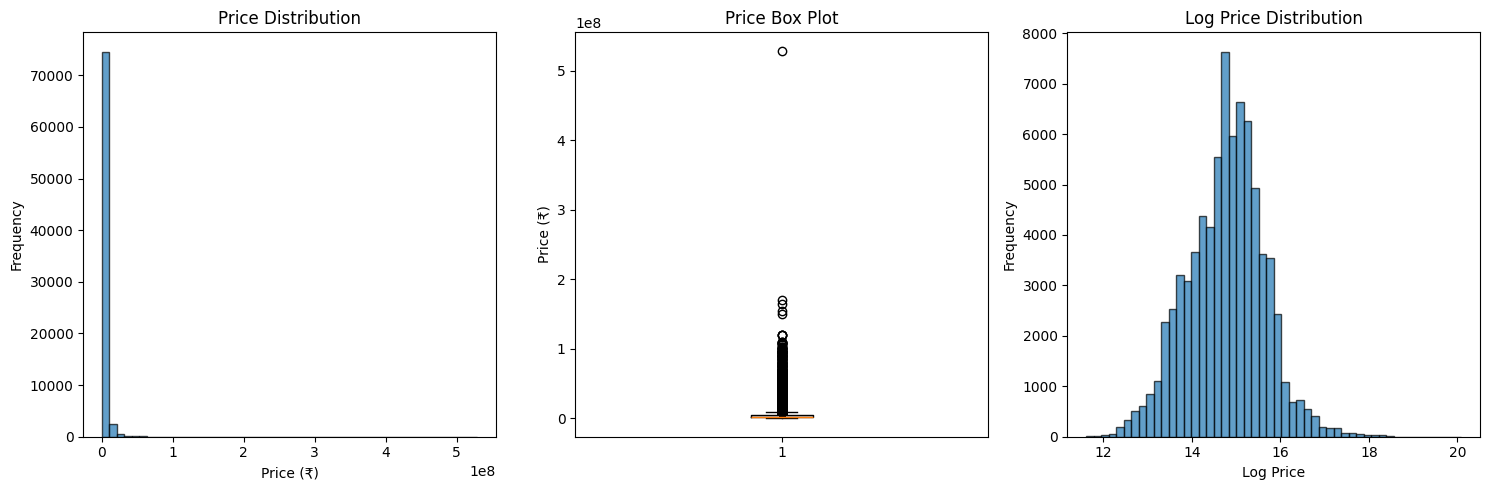

In [23]:
# Price distribution analysis
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(y_cars, bins=50, edgecolor='black', alpha=0.7)
plt.title('Price Distribution')
plt.xlabel('Price (₹)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.boxplot(y_cars)
plt.title('Price Box Plot')
plt.ylabel('Price (₹)')

plt.subplot(1, 3, 3)
plt.hist(np.log(y_cars), bins=50, edgecolor='black', alpha=0.7)
plt.title('Log Price Distribution')
plt.xlabel('Log Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
#observations:
#Price distribution: most carsare priced under 1cr and graph is extemly right skewed as mean is greater then median
#Box plot: Median price is around 10 to 15 lac and cars above 5cr are massive outlier you can see the dot above 5 in the plot and most cars falls in 5 to 25 lac range
#After log transformation near normal distribution as graph is almost normal this suggest us to Use log(price) as target for better model performance.

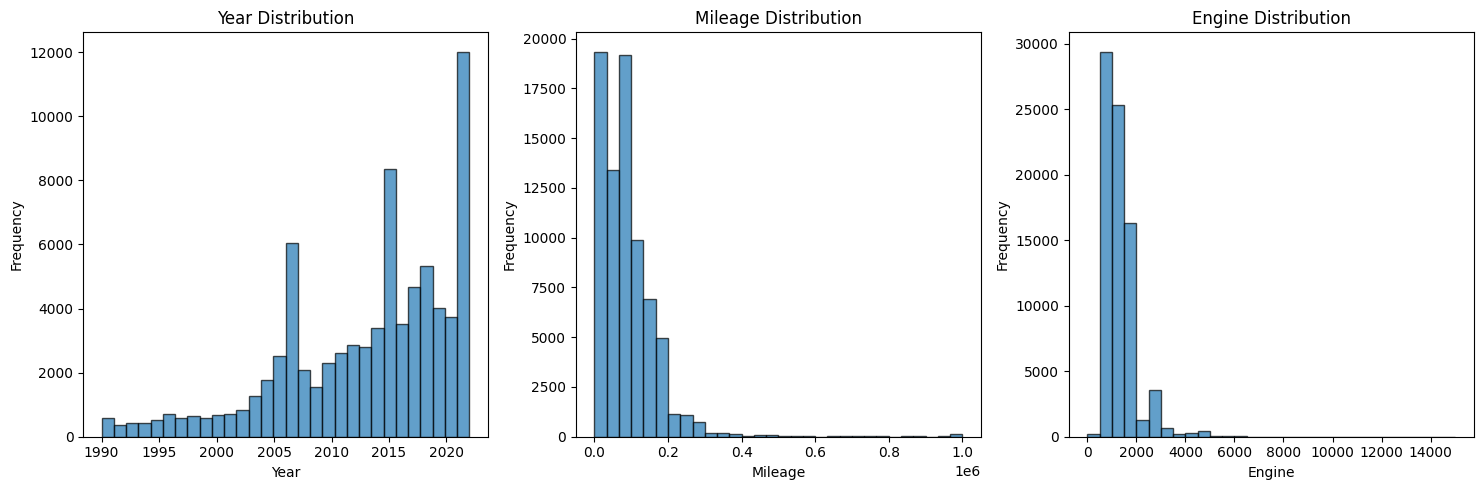

In [24]:
# Distribution of numerical features
numerical_features = ['year', 'mileage', 'engine']
plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i+1)
    plt.hist(df_cars[col], bins=30, edgecolor='black', alpha=0.7)
    plt.title(f'{col.title()} Distribution')
    plt.xlabel(col.title())
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
#observations:
#Year Dist: most cars are from 2015 to 2020 highest frequency after 2020 and then at 2015 and very limited data before 2005
#Milage Dist: most cars have low milage 0-100km peak at 0-50km cars with milage above 500km are very rare outliers
#Engine Dist: popular engine sizes around 1000cc, 1300cc, 1600cc

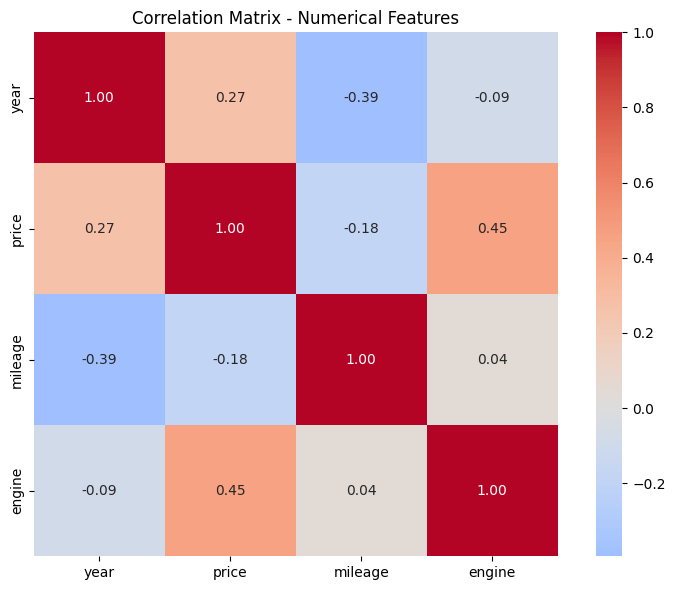

Strong correlations with price:
price      1.000000
engine     0.454278
year       0.266842
mileage    0.176551
Name: price, dtype: float64


In [25]:
# Correlation matrix for numerical features
numerical_data = df_cars[['year', 'price', 'mileage', 'engine']].copy()
correlation_matrix = numerical_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

print("Strong correlations with price:")
price_corr = correlation_matrix['price'].abs().sort_values(ascending=False)
print(price_corr)
#observations:
#Engine n price +0.45 strongest pridictor amoung numerical features
#Year n Mileage is -0.39  Newer cars have lower mileage (expected)
#Engine n Mileage: +0.04  No relationship 
#Year n Engine: -0.09  Very weak relationship


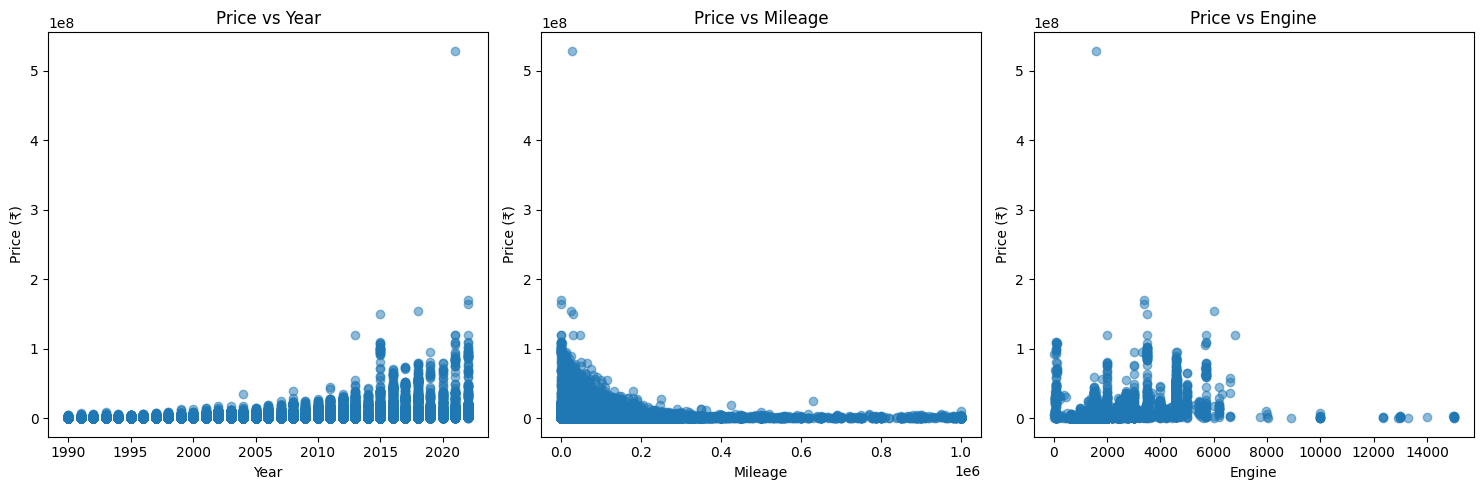

In [26]:
# Scatter plots of price vs numerical features
plt.figure(figsize=(15, 5))

for i, col in enumerate(['year', 'mileage', 'engine']):
    plt.subplot(1, 3, i+1)
    plt.scatter(df_cars[col], df_cars['price'], alpha=0.5)
    plt.title(f'Price vs {col.title()}')
    plt.xlabel(col.title())
    plt.ylabel('Price (₹)')

plt.tight_layout()
plt.show()
#observation:
#Weak correlations overall  Categorical features (make, model, city) likely more important
#No multicollinearity issues  All correlations <0.5 between predictors
#Engine displacement  Key differentiator (economy vs luxury)
#Recent year bias  Model will favor newer cars

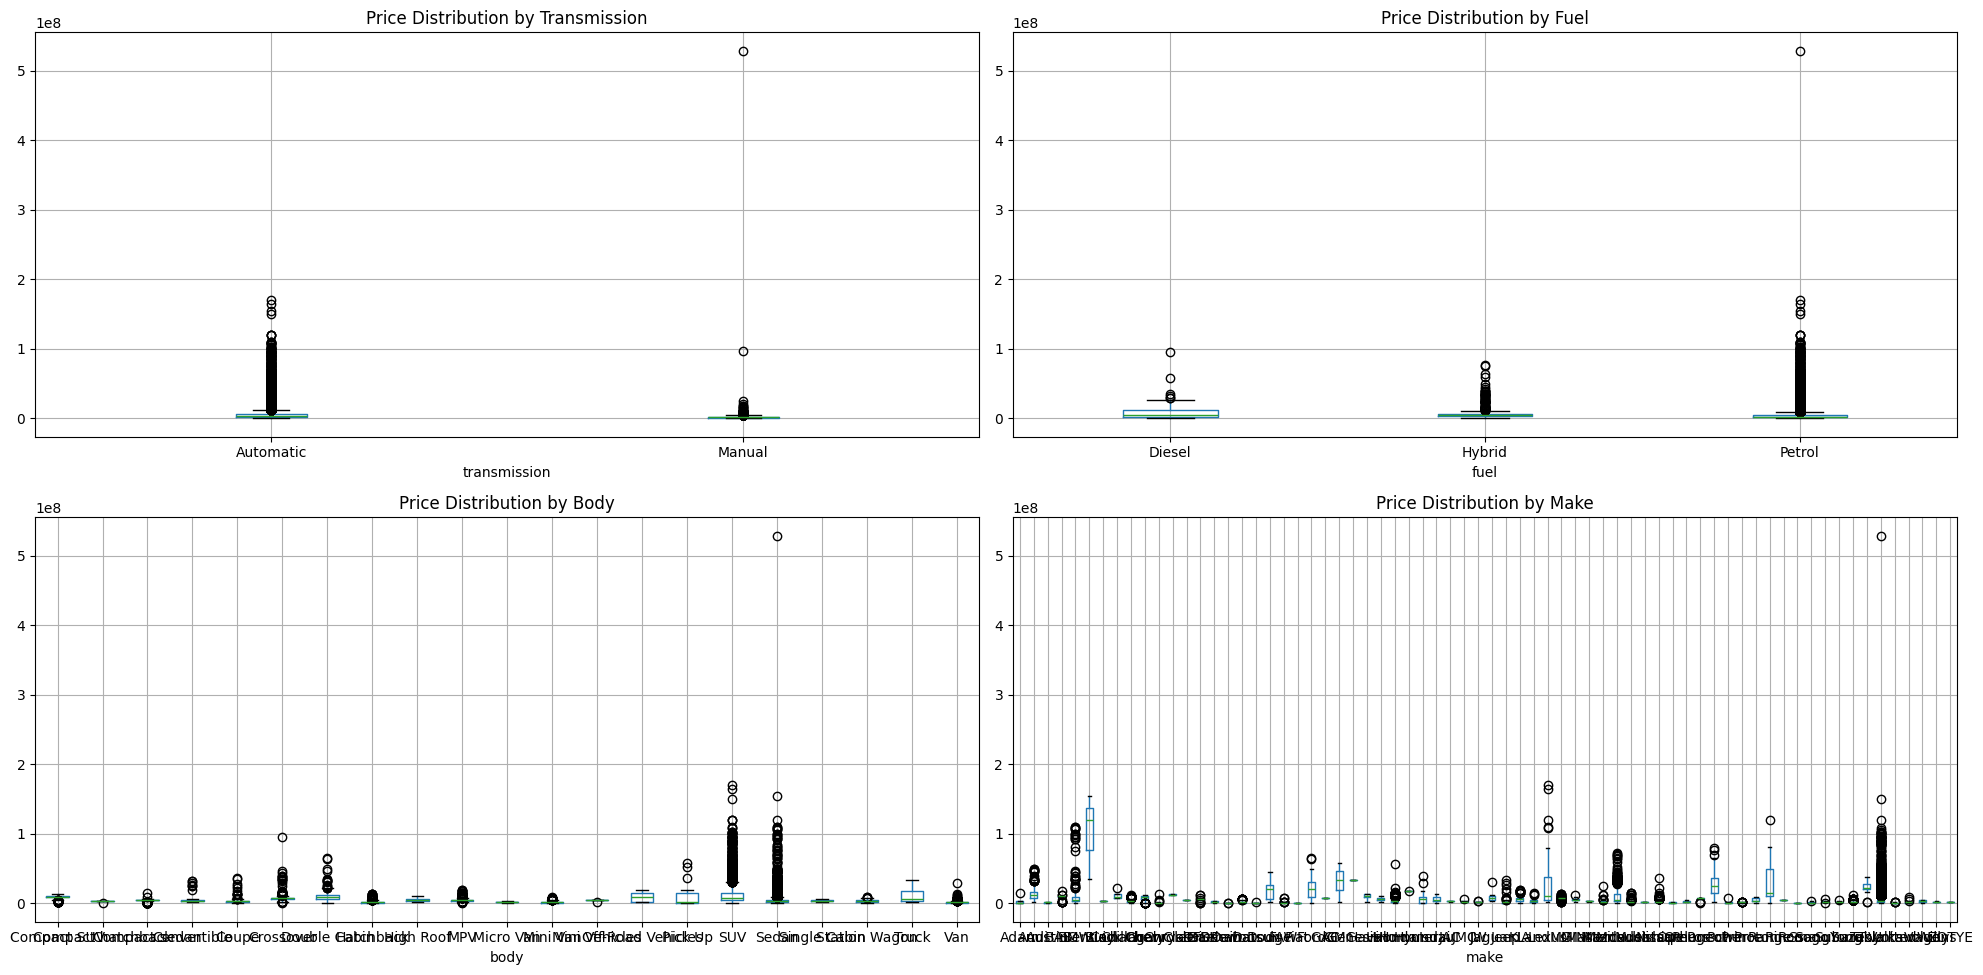

In [30]:
# Analyze categorical features impact on price
categorical_features = ['transmission', 'fuel', 'body', 'make']
plt.figure(figsize=(20, 10))

for i, col in enumerate(categorical_features):
    plt.subplot(2, 2, i+1)
    df_cars.boxplot(column='price', by=col, ax=plt.gca())
    plt.title(f'Price Distribution by {col.title()}')
    plt.suptitle('')  # Remove default title
    
plt.tight_layout()
plt.show()

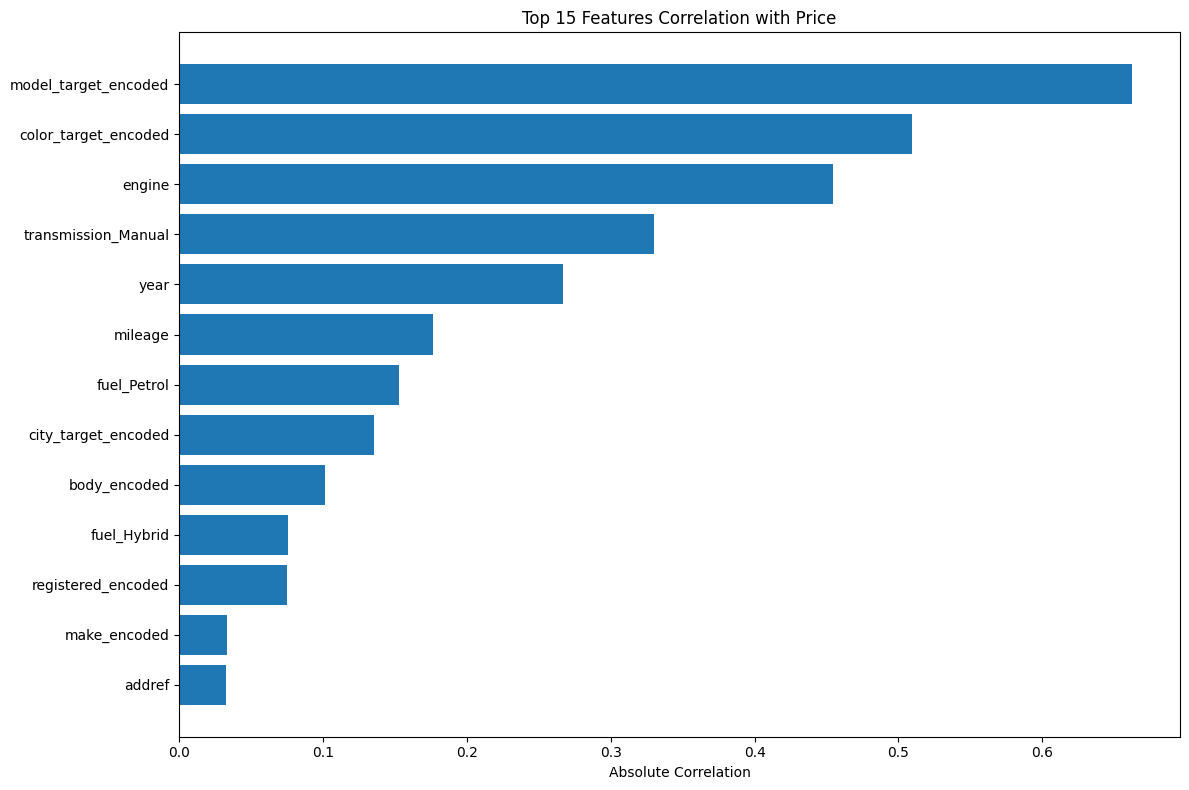

Top 10 features correlated with price:
model_target_encoded    0.662582
color_target_encoded    0.509647
engine                  0.454278
transmission_Manual     0.330208
year                    0.266842
mileage                 0.176551
fuel_Petrol             0.152964
city_target_encoded     0.135282
body_encoded            0.101553
fuel_Hybrid             0.075916
dtype: float64


In [28]:
# Correlation of encoded features with price
feature_correlations = X_cars.corrwith(y_cars).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
top_features = feature_correlations.head(15)
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.title('Top 15 Features Correlation with Price')
plt.xlabel('Absolute Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features correlated with price:")
print(feature_correlations.head(10))
#observations:
#Target encoding DOMINATES  Your encoding strategy was perfect!
#Model > Color > Engine  Specific car model most important
#City correlation moderate  Regional pricing differences exist
#Make_encoded surprisingly low  Brand less important than specific model

In [29]:
# Check for anomalies and data quality
print("DATA QUALITY ANALYSIS: ")

print(f"\n1. Dataset size: {df_cars.shape[0]:,} cars")
print(f"2. Features after encoding: {X_cars.shape[1]}")

print("\n3. Price range analysis:")
print(f"   Cars under ₹5L: {(y_cars < 500000).sum():,} ({(y_cars < 500000).mean()*100:.1f}%)")
print(f"   Cars ₹5L-15L: {((y_cars >= 500000) & (y_cars < 1500000)).sum():,} ({((y_cars >= 500000) & (y_cars < 1500000)).mean()*100:.1f}%)")
print(f"   Cars above ₹15L: {(y_cars >= 1500000).sum():,} ({(y_cars >= 1500000).mean()*100:.1f}%)")

print("\n4. Potential outliers (price > mean + 3*std):")
outlier_threshold = y_cars.mean() + 3*y_cars.std()
outliers = y_cars > outlier_threshold
print(f"   {outliers.sum()} cars above ₹{outlier_threshold:,.0f}")

print(f"\n5. Year range: {df_cars['year'].min()} to {df_cars['year'].max()}")
print(f"6. Average mileage: {df_cars['mileage'].mean():,.0f} km")

DATA QUALITY ANALYSIS: 

1. Dataset size: 77,878 cars
2. Features after encoding: 13

3. Price range analysis:
   Cars under ₹5L: 2,439 (3.1%)
   Cars ₹5L-15L: 17,594 (22.6%)
   Cars above ₹15L: 57,845 (74.3%)

4. Potential outliers (price > mean + 3*std):
   880 cars above ₹21,090,738

5. Year range: 1990.0 to 2022.0
6. Average mileage: 91,109 km
